### Air Quality Index (AQI) Analysis of Delhi

Delhi faces severe air pollution due to rapid urbanization, vehicular emissions,
industrial activities, and seasonal factors. This project analyzes air quality data
to understand pollutant behavior, seasonal trends, and their impact on public health.

## Objectives:
- Analyze key pollutants affecting Delhi's air quality
- Study seasonal and monthly AQI trends
- Identify critical pollution periods
- Provide insights for air quality improvement strategies

#### 2. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12,6)
sns.set_style("whitegrid")

#### 3. Load Dataset

In [3]:
df = pd.read_csv("c:\\Users\\Pooja\\OneDrive\\Desktop\\delhiaqi.csv")
df.head()

,date,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,2023-01-01 00:00:00,1655.58,1.66,39.41,5.90,17.88,169.29,194.64,5.83
1,2023-01-01 01:00:00,1869.20,6.82,42.16,1.99,22.17,182.84,211.08,7.66
2,2023-01-01 02:00:00,2510.07,27.72,43.87,0.02,30.04,220.25,260.68,11.40
3,2023-01-01 03:00:00,3150.94,55.43,44.55,0.85,35.76,252.90,304.12,13.55
4,2023-01-01 04:00:00,3471.37,68.84,45.24,5.45,39.10,266.36,322.80,14.19


#### 4. Data Preprocessing

In [4]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['hour'] = df['date'].dt.hour

df.isnull().sum()

date     0
co       0
no       0
no2      0
o3       0
so2      0
pm2_5    0
pm10     0
nh3      0
year     0
month    0
hour     0
dtype: int64

#### 5. Research Questions 

1. How does air pollution vary across seasons in Delhi?
2. Which pollutants contribute most to poor air quality?
3. What months experience the highest pollution levels?
4. How are different pollutants correlated?

#### 6. AQI Trend Analysis (PM2.5 & PM10)

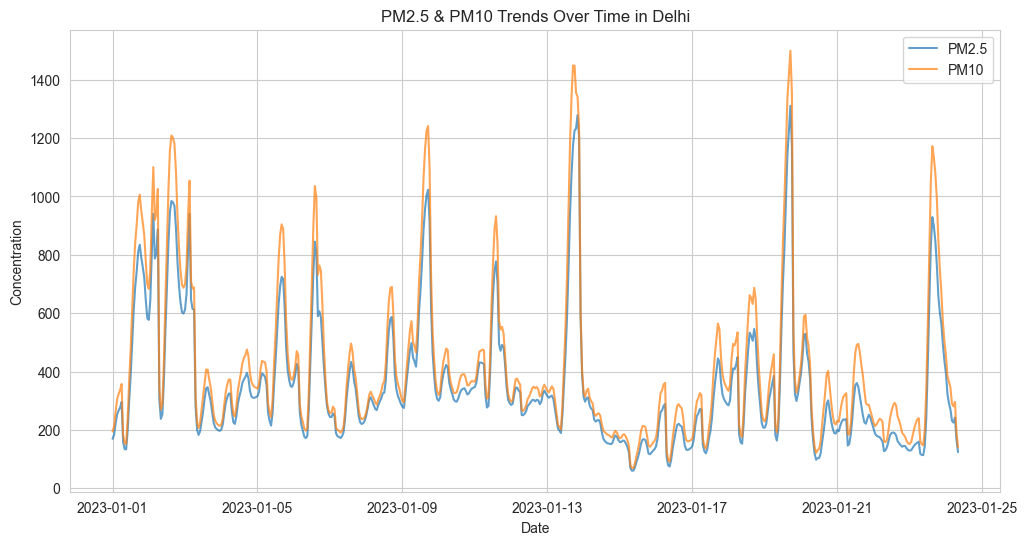

In [6]:
plt.plot(df['date'], df['pm2_5'], label='PM2.5', alpha=0.7)
plt.plot(df['date'], df['pm10'], label='PM10', alpha=0.7)

plt.title("PM2.5 & PM10 Trends Over Time in Delhi")
plt.xlabel("Date")
plt.ylabel("Concentration")
plt.legend()
plt.show()

#### 7. Monthly Pollution Analysis

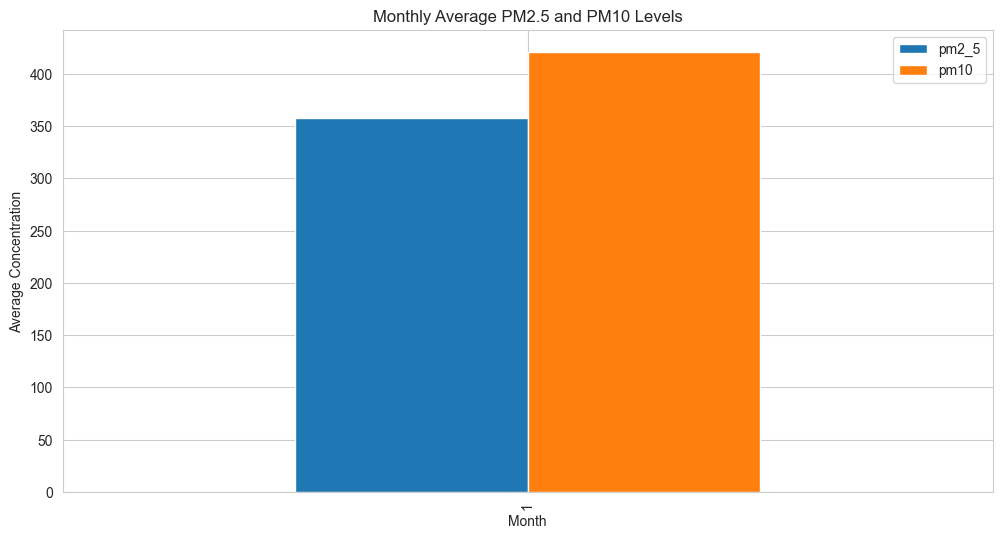

In [7]:
monthly_avg = df.groupby('month')[['pm2_5', 'pm10']].mean()

monthly_avg.plot(kind='bar')
plt.title("Monthly Average PM2.5 and PM10 Levels")
plt.xlabel("Month")
plt.ylabel("Average Concentration")
plt.show()

#### 8. Seasonal Analysis 

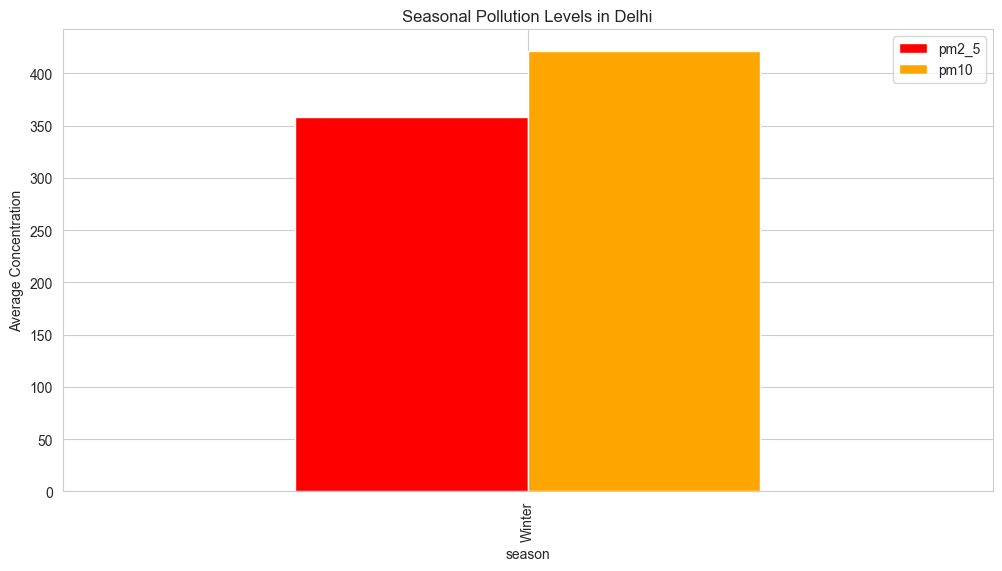

In [8]:
def get_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Summer'
    elif month in [6,7,8]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

df['season'] = df['month'].apply(get_season)

seasonal_avg = df.groupby('season')[['pm2_5', 'pm10']].mean()

seasonal_avg.plot(kind='bar', color=['red','orange'])
plt.title("Seasonal Pollution Levels in Delhi")
plt.ylabel("Average Concentration")
plt.show()

#### 9. Pollutant Contribution Comparison

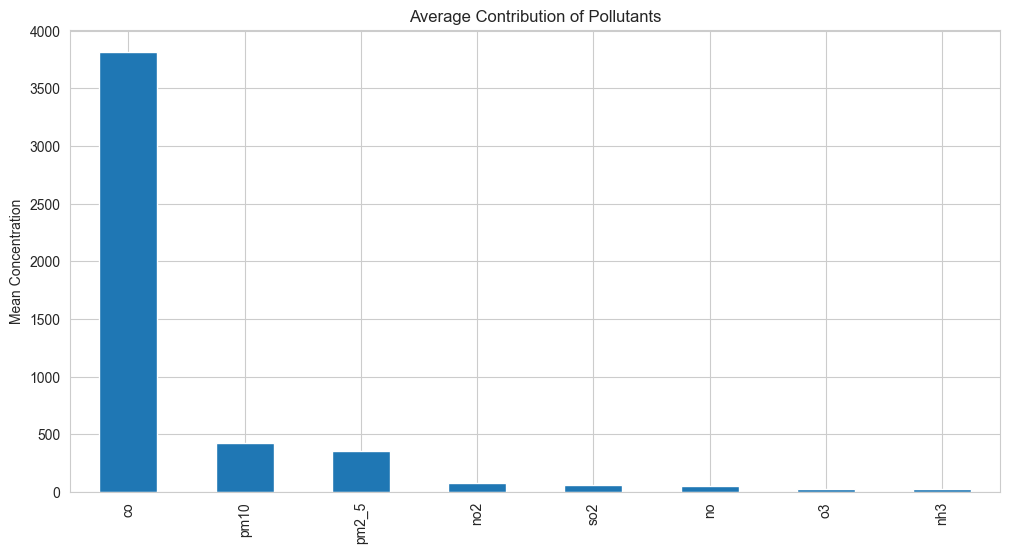

In [9]:
pollutants = ['co','no','no2','o3','so2','pm2_5','pm10','nh3']
pollutant_means = df[pollutants].mean().sort_values(ascending=False)

pollutant_means.plot(kind='bar')
plt.title("Average Contribution of Pollutants")
plt.ylabel("Mean Concentration")
plt.show()

#### 10. Correlation Heatmap (Advanced Visualization)

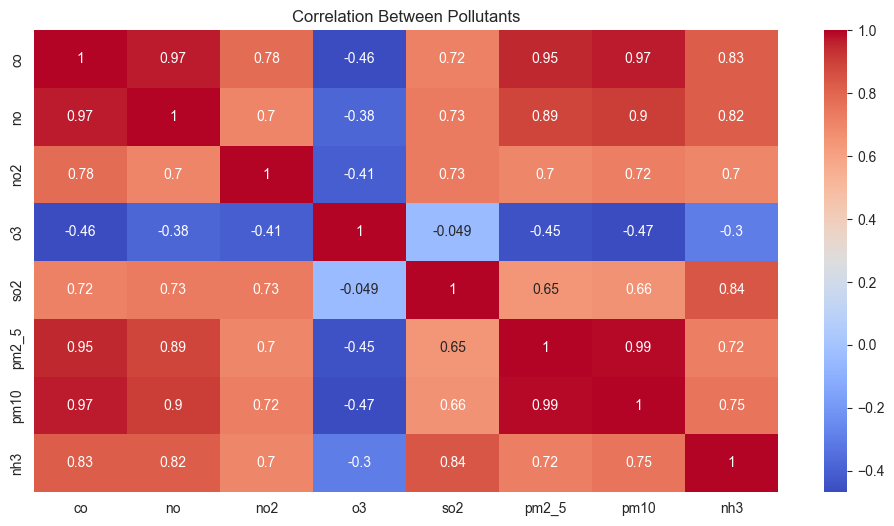

In [10]:
corr = df[pollutants].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Between Pollutants")
plt.show()

#### 11. Hourly Pollution Pattern (Advanced Insight)

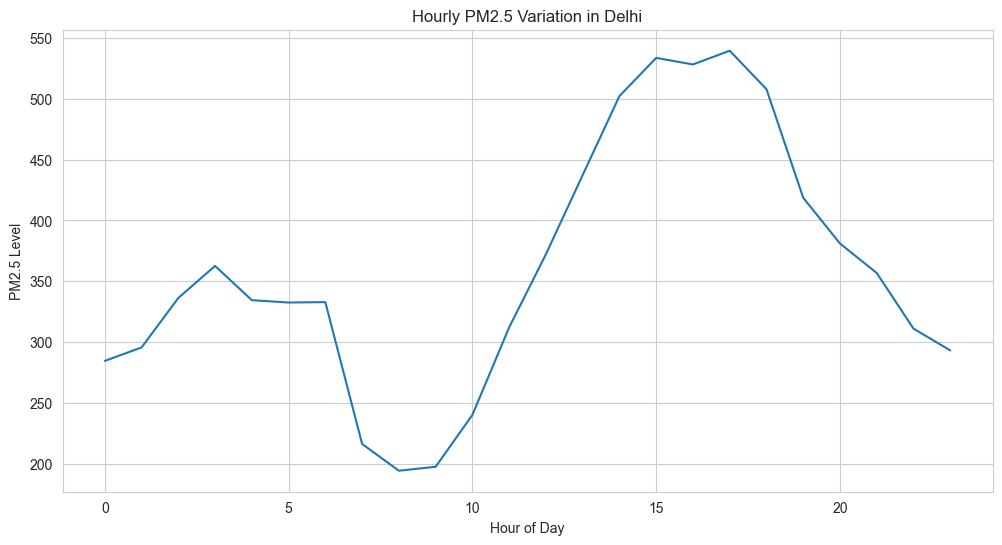

In [11]:
hourly_avg = df.groupby('hour')['pm2_5'].mean()

plt.plot(hourly_avg)
plt.title("Hourly PM2.5 Variation in Delhi")
plt.xlabel("Hour of Day")
plt.ylabel("PM2.5 Level")
plt.show()

#### 12. Statistical Summary

In [12]:
df[['pm2_5','pm10']].describe()

,pm2_5,pm10
count,561.000000,561.000000
mean,358.256364,420.988414
std,227.359117,271.287026
min,60.100000,69.080000
25%,204.450000,240.900000
50%,301.170000,340.900000
75%,416.650000,482.570000
max,1310.200000,1499.270000


#### 13. Day vs Night Pollution Comparison

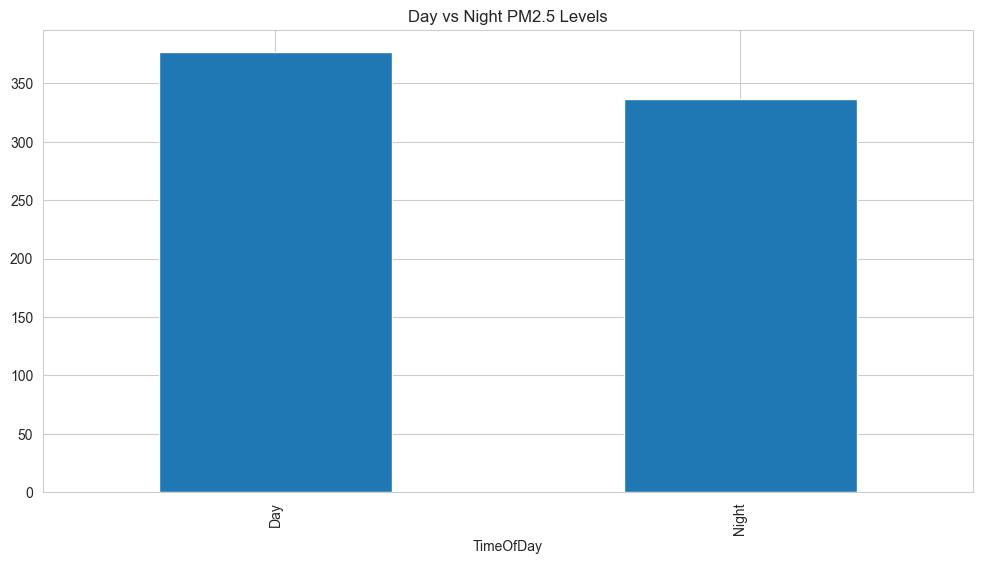

In [13]:
df['TimeOfDay'] = df['hour'].apply(lambda x: 'Day' if 6 <= x <= 18 else 'Night')

df.groupby('TimeOfDay')['pm2_5'].mean().plot(kind='bar')
plt.title("Day vs Night PM2.5 Levels")
plt.show()

####  14. Worst Pollution Days Analysis

In [14]:
worst_days = df.sort_values(by='pm2_5', ascending=False).head(10)
worst_days[['date','pm2_5','pm10']]

,date,pm2_5,pm10
449,2023-01-19 17:00:00,1310.20,1499.27
308,2023-01-13 20:00:00,1278.35,1342.18
307,2023-01-13 19:00:00,1232.62,1355.20
448,2023-01-19 16:00:00,1228.04,1415.28
306,2023-01-13 18:00:00,1225.39,1448.70
309,2023-01-13 21:00:00,1204.33,1238.17
305,2023-01-13 17:00:00,1174.70,1448.28
450,2023-01-19 18:00:00,1170.46,1351.85
447,2023-01-19 15:00:00,1142.61,1335.34
304,2023-01-13 16:00:00,1074.91,1337.24


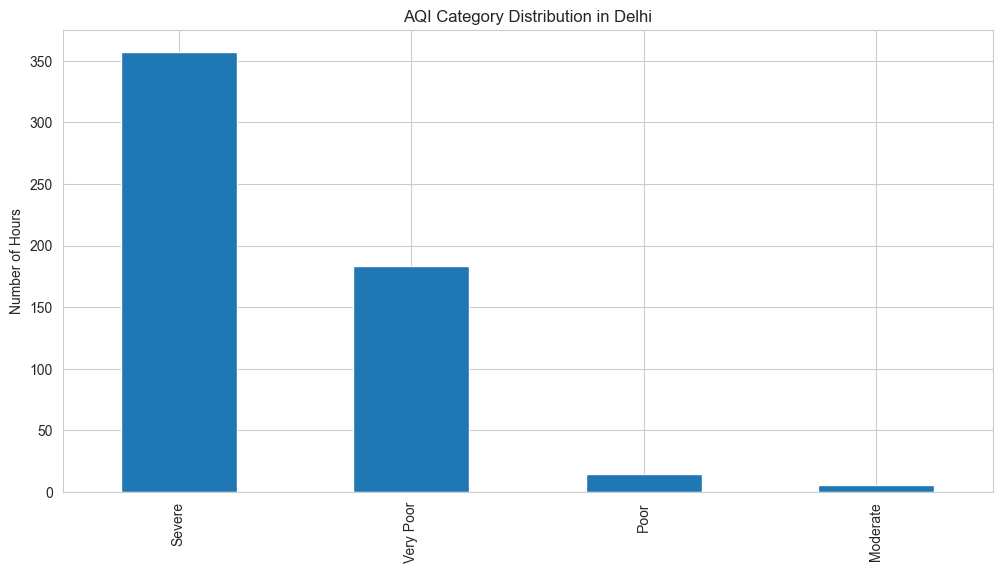

In [16]:
def aqi_category(pm):
    if pm <= 30:
        return 'Good'
    elif pm <= 60:
        return 'Satisfactory'
    elif pm <= 90:
        return 'Moderate'
    elif pm <= 120:
        return 'Poor'
    elif pm <= 250:
        return 'Very Poor'
    else:
        return 'Severe'
df['AQI_Category'] = df['pm2_5'].apply(aqi_category)
df['AQI_Category'].value_counts().plot(kind='bar')
plt.title("AQI Category Distribution in Delhi")
plt.ylabel("Number of Hours")
plt.show()

##### Key Findings:
- PM2.5 and PM10 are the major contributors to poor air quality in Delhi
- Winter season shows extremely high pollution levels
- Pollutants like NO₂ and CO show strong correlation with particulate matter
- Night-time pollution levels are consistently higher than daytime levels